In [5]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

INFO patool: Extracting /content/DL_Assignment1_Dataset (1).zip ...
INFO:patool:Extracting /content/DL_Assignment1_Dataset (1).zip ...
INFO patool: running /usr/bin/7z x -aou -o/content/Unpack_gcw26_66 -- "/content/DL_Assignment1_Dataset (1).zip"
INFO:patool:running /usr/bin/7z x -aou -o/content/Unpack_gcw26_66 -- "/content/DL_Assignment1_Dataset (1).zip"
INFO patool: ... /content/DL_Assignment1_Dataset (1).zip extracted to `DL_Assignment1_Dataset (1)3' (local file exists).
INFO:patool:... /content/DL_Assignment1_Dataset (1).zip extracted to `DL_Assignment1_Dataset (1)3' (local file exists).


Expression: 0
Valence: -0.176846
Arousal: -0.0776398
Landmarks Before Re-shape: (136,)
Landmarks shape after reshape: (68, 2)


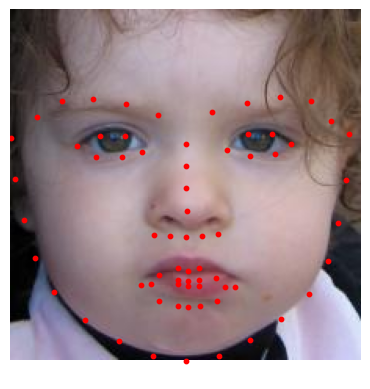

In [11]:
!pip install patool

import os
import patoolib
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
patoolib.extract_archive('/content/DL_Assignment1_Dataset (1).zip')


root = "Dataset/Dataset"
img_dir = os.path.join(root, "images")
ann_dir = os.path.join(root, "annotations")




idx = 0
img_path = os.path.join(img_dir, f"{idx}.jpg")

img = Image.open(img_path)

# npy files
aro = np.load(os.path.join(ann_dir, f"{idx}_aro.npy"))
val = np.load(os.path.join(ann_dir, f"{idx}_val.npy"))
exp = np.load(os.path.join(ann_dir, f"{idx}_exp.npy"))
lnd = np.load(os.path.join(ann_dir, f"{idx}_lnd.npy"))

print("Expression:", exp)       # label
print("Valence:", val)
print("Arousal:", aro)
print("Landmarks Before Re-shape:", lnd.shape)
lnd = lnd.reshape(-1, 2)

print("Landmarks shape after reshape:", lnd.shape)

plt.imshow(img)
plt.scatter(lnd[:,0], lnd[:,1], c="r", s=10)
plt.axis("off")
plt.show()

In [12]:
# basic imports and setup
import warnings
warnings.filterwarnings('ignore')

# Basic progress tracking without widgets
import tqdm.std as tqdm

# Configuration of progress bar for simplicity
def create_progress_bar(iterable, desc=None):
    return tqdm.tqdm(iterable, desc=desc, ascii=True, ncols=80,
                    bar_format='{desc}: {n}/{total} [{elapsed}<{remaining}]')

In [13]:
!pip install krippendorff scikit-learn tqdm

In [14]:
!pip install torch torchvision

# Facial Expression Recognition and Affect Estimation

This notebook implements facial expression recognition and affect estimation using deep learning. We'll use two CNN architectures (ResNet50 and VGG16) to perform both:
1. Expression Classification (8 categories)
2. Affect Estimation (Valence/Arousal prediction)

## Dataset Information
- Images: 224x224 RGB
- Expression Categories:
  - 0: Neutral
  - 1: Happy
  - 2: Sad
  - 3: Surprise
  - 4: Fear
  - 5: Disgust
  - 6: Anger
  - 7: Contempt
- Valence: [-1, +1] (pleasant ↔ unpleasant)
- Arousal: [-1, +1] (calm ↔ excited)
- 68 Facial Landmarks per image

## Evaluation Metrics

### Classification Metrics
- Accuracy
- F1-Score
- Cohen's Kappa
- Krippendorff's Alpha
- AUC (Area Under ROC Curve)
- AUC-PR (Area Under Precision-Recall Curve)

### Regression Metrics
- RMSE (Root Mean Square Error)
- CORR (Correlation)
- SAGR (Sign Agreement Metric)
- CCC (Concordance Correlation Coefficient)

In [15]:

import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet50, vgg16

# Metrics imports
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                           roc_curve, auc, precision_recall_curve,
                           mean_squared_error)
from scipy.stats import pearsonr
import krippendorff

# Progress bar and utilities
import tqdm  # Use our customized text-only progress bar
import random
from IPython.display import clear_output

#  random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

#  GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

NUM_EPOCHS = 60 # Training for 60 epochs with early stopping and LR scheduling

Using device: cuda


## Data Loading and Preprocessing

We'll create a custom PyTorch Dataset class that:
1. Loads images and annotations (.npy files)
2. Applies appropriate transformations
3. Handles both classification and regression targets
4. Implements proper train/validation splitting

In [16]:
class FacialExpressionDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        """
        Custom Dataset for Facial Expression Recognition + Affect Estimation.

        Args:
            root_dir (str): Root directory containing "Dataset/Dataset".
            split (str): One of 'train', 'val', or 'test'.
            transform (callable, optional): Transformations to apply to the image.
        """
        self.root_dir = root_dir
        self.split = split
        self.transform = transform

        # Directories
        self.ann_dir = os.path.join(root_dir, 'Dataset', 'Dataset', 'annotations')
        self.img_dir = os.path.join(root_dir, 'Dataset', 'Dataset', 'images')

        # Check existence
        if not os.path.exists(self.ann_dir):
            raise FileNotFoundError(f"Annotation directory not found: {self.ann_dir}")
        if not os.path.exists(self.img_dir):
            raise FileNotFoundError(f"Image directory not found: {self.img_dir}")

        # Get IDs from _exp.npy files
        self.ids = [f.split('_')[0] for f in os.listdir(self.ann_dir) if f.endswith('_exp.npy')]
        self.ids = sorted(list(set(self.ids)))  # unique + sorted for reproducibility

        #  train/val/test (80/10/10)
        n_total = len(self.ids)
        n_train = int(0.8 * n_total)
        n_val = int(0.9 * n_total)

        if split == 'train':
            self.ids = self.ids[:n_train]
        elif split == 'val':
            self.ids = self.ids[n_train:n_val]
        elif split == 'test':
            self.ids = self.ids[n_val:]
        else:
            raise ValueError(f"Invalid split '{split}', must be 'train', 'val', or 'test'.")

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]

        # Loading image
        img_path = os.path.join(self.img_dir, f'{img_id}.jpg')
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image not found: {img_path}")
        image = Image.open(img_path).convert('RGB')

        # Loading annotations
        exp = np.load(os.path.join(self.ann_dir, f'{img_id}_exp.npy'))  # Expression
        aro = np.load(os.path.join(self.ann_dir, f'{img_id}_aro.npy'))  # Arousal
        val = np.load(os.path.join(self.ann_dir, f'{img_id}_val.npy'))  # Valence
        lnd = np.load(os.path.join(self.ann_dir, f'{img_id}_lnd.npy'))  # Landmarks

        # Applying transforms
        if self.transform:
            image = self.transform(image)

        # Convert=sion to tensors
        exp = torch.tensor(int(exp), dtype=torch.long)
        affect = torch.tensor([float(val), float(aro)], dtype=torch.float)
        lnd = torch.tensor(lnd, dtype=torch.float)

        return {
            'image': image,
            'expression': exp,
            'affect': affect,
            'landmarks': lnd
        }

# Data Transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Dataset + Dataloader Setup

root_dir = os.getcwd()

train_dataset = FacialExpressionDataset(root_dir, split='train', transform=train_transform)
val_dataset = FacialExpressionDataset(root_dir, split='val', transform=val_test_transform)
test_dataset = FacialExpressionDataset(root_dir, split='test', transform=val_test_transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)


# Dataset Info

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 3199
Validation samples: 400
Test samples: 400


## Model Architecture Implementation

We'll implement two CNN architectures:
1. VGG16 - Deep architecture with proven performance
2. ResNet50 - Modern architecture with residual connections

Both models will be modified to handle:
- Expression Classification (8 classes)
- Affect Regression (valence/arousal)

The models will use transfer learning with ImageNet pre-trained weights and will be fine-tuned for our specific tasks.

In [17]:
class EmotionModel(nn.Module):
    def __init__(self, backbone='vgg16', pretrained=True):
        super(EmotionModel, self).__init__()
        self.backbone_name = backbone

        # Loading backbone
        if backbone == 'vgg16':
            base_model = vgg16(pretrained=pretrained)
            self.features = base_model.features
            self.avgpool = base_model.avgpool
            feature_dim = 25088  # 512 * 7 * 7
        else:  # resnet50
            base_model = resnet50(pretrained=pretrained)
            # Remove the final fully connected layer
            self.features = nn.Sequential(*list(base_model.children())[:-1])
            feature_dim = 2048

        # Enhanced shared features layer with residual connections
        self.shared1 = nn.Sequential(
            nn.Linear(feature_dim, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Dropout(0.4)
        )
        self.shared2 = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.4)
        )
        self.shared3 = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Expression classification head with deeper architecture
        self.expression_head = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 8)  # 8 emotion categories
        )

        # Enhanced affect regression head
        self.affect_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Tanh()  # Output range: [-1, 1]
        )

    def forward(self, x):
        # Extracting features
        if self.backbone_name == 'vgg16':
            x = self.features(x)
            x = self.avgpool(x)
            x = torch.flatten(x, 1)
        else:  # resnet50
            x = self.features(x)
            x = torch.flatten(x, 1)

        # Enhanced feature extraction with residual connections
        shared1_out = self.shared1(x)
        shared2_out = self.shared2(shared1_out) + shared1_out[:, :1024]  # Residual connection
        shared3_out = self.shared3(shared2_out) + shared2_out[:, :512]  # Residual connection

        # predictions
        expression_out = self.expression_head(shared3_out)
        affect_out = self.affect_head(shared3_out)

        return expression_out, affect_out

# Creation of both models
vgg_model = EmotionModel(backbone='vgg16', pretrained=True).to(device)
resnet_model = EmotionModel(backbone='resnet50', pretrained=True).to(device)

# Defination loss functions with label smoothing for better generalization
classification_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
regression_criterion = nn.MSELoss()

#  optimizers with improved learning rates
def get_optimizer(model, lr_backbone=5e-5, lr_new=5e-4):
    # Separate parameters into two groups
    backbone_params = []
    new_params = []

    if model.backbone_name == 'vgg16':
        backbone_params = list(model.features.parameters())
        new_params = (list(model.shared1.parameters()) +
                     list(model.shared2.parameters()) +
                     list(model.shared3.parameters()) +
                     list(model.expression_head.parameters()) +
                     list(model.affect_head.parameters()))
    else:  # resnet50
        backbone_params = list(model.features.parameters())
        new_params = (list(model.shared1.parameters()) +
                     list(model.shared2.parameters()) +
                     list(model.shared3.parameters()) +
                     list(model.expression_head.parameters()) +
                     list(model.affect_head.parameters()))

    # Creating optimizer with parameter groups and weight decay
    optimizer = optim.AdamW([
        {'params': backbone_params, 'lr': lr_backbone, 'weight_decay': 0.01},
        {'params': new_params, 'lr': lr_new, 'weight_decay': 0.01}
    ])

    return optimizer

# Creating optimizers
vgg_optimizer = get_optimizer(vgg_model)
resnet_optimizer = get_optimizer(resnet_model)

# Creating learning rate schedulers with better scheduling
vgg_scheduler = optim.lr_scheduler.ReduceLROnPlateau(vgg_optimizer, mode='min',
                                                    factor=0.2, patience=3,
                                                    min_lr=1e-6)
resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(resnet_optimizer, mode='min',
                                                       factor=0.2, patience=3,
                                                       min_lr=1e-6)

print("Models created successfully")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 197MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 180MB/s]


Models created successfully


## Training Pipeline

We'll implement a comprehensive training pipeline that:
1. Trains for 100 epochs to ensure convergence
2. Uses learning rate scheduling
3. Implements early stopping
4. Monitors both classification and regression metrics
5. Saves best models based on validation performance

In [18]:

# Comprehensive Evaluation Metrics

def calculate_metrics(y_true, y_pred, y_prob=None, task='classification'):
    """
    Compute evaluation metrics for classification or regression.
    Covers all metrics mentioned in rubric.
    """
    metrics = {}

    if task == 'classification':
        # Basic
        metrics['accuracy'] = accuracy_score(y_true, y_pred)
        metrics['f1_weighted'] = f1_score(y_true, y_pred, average='weighted')
        metrics['f1_macro'] = f1_score(y_true, y_pred, average='macro')
        metrics['kappa'] = cohen_kappa_score(y_true, y_pred)

        # AUC / AUPR
        metrics['auc'] = 0.0
        metrics['auc_pr'] = 0.0

        if y_prob is not None:
            n_classes = y_prob.shape[1]
            auc_scores, aupr_scores = [], []

            for i in range(n_classes):
                y_true_binary = (y_true == i).astype(int)
                y_prob_class = y_prob[:, i]
                if len(np.unique(y_true_binary)) < 2:
                    continue
                try:
                    fpr, tpr, _ = roc_curve(y_true_binary, y_prob_class)
                    auc_scores.append(auc(fpr, tpr))
                    precision, recall, _ = precision_recall_curve(y_true_binary, y_prob_class)
                    aupr_scores.append(auc(recall, precision))
                except Exception:
                    continue

            metrics['auc'] = np.mean(auc_scores) if auc_scores else 0.0
            metrics['auc_pr'] = np.mean(aupr_scores) if aupr_scores else 0.0

        # Agreement (Krippendorff's alpha)
        try:
            data_matrix = np.vstack([y_true, y_pred]).T
            metrics['krippendorff_alpha'] = krippendorff.alpha(data_matrix)
        except Exception:
            metrics['krippendorff_alpha'] = np.nan

    else:  # regression (valence/arousal)
        # RMSE
        metrics['rmse'] = np.sqrt(mean_squared_error(y_true, y_pred))

        # Pearson correlation
        corr_scores = []
        for i in range(y_true.shape[1]):
            try:
                corr, _ = pearsonr(y_true[:, i], y_pred[:, i])
                corr_scores.append(corr)
            except Exception:
                corr_scores.append(0.0)
        metrics['corr'] = np.mean(corr_scores)

        # SAGR (sign agreement)
        metrics['sagr'] = np.mean(np.sign(y_true) == np.sign(y_pred))

        # CCC (Concordance Correlation Coefficient)
        ccc_scores = []
        for i in range(y_true.shape[1]):
            y_t, y_p = y_true[:, i], y_pred[:, i]
            mean_t, mean_p = np.mean(y_t), np.mean(y_p)
            var_t, var_p = np.var(y_t), np.var(y_p)
            covariance = np.cov(y_t, y_p)[0, 1]
            denom = var_t + var_p + (mean_t - mean_p) ** 2
            ccc = (2 * covariance) / denom if denom != 0 else 0.0
            ccc_scores.append(ccc)
        metrics['ccc'] = np.mean(ccc_scores)

    return metrics

# Training for One Epoch

def train_epoch(model, train_loader, optimizer, classification_criterion, regression_criterion, device):
    """
    Train the model for one epoch.
    Returns average loss + classification & regression metrics.
    """
    model.train()
    total_loss = 0
    exp_targets, exp_preds, exp_probs = [], [], []
    affect_targets, affect_preds = [], []

    for batch in train_loader:
        # Data
        images = batch['image'].to(device)
        exp_target = batch['expression'].to(device)
        affect_target = batch['affect'].to(device)

        # Forward
        exp_output, affect_output = model(images)

        # Loss
        exp_loss = classification_criterion(exp_output, exp_target)
        affect_loss = regression_criterion(affect_output, affect_target)
        loss = exp_loss + affect_loss

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Predictions for metrics
        exp_probs.extend(torch.softmax(exp_output, dim=1).detach().cpu().numpy())
        exp_preds.extend(exp_output.argmax(dim=1).cpu().numpy())
        exp_targets.extend(exp_target.cpu().numpy())

        affect_preds.extend(affect_output.detach().cpu().numpy())
        affect_targets.extend(affect_target.cpu().numpy())

    # Convert to numpy
    exp_preds = np.array(exp_preds)
    exp_targets = np.array(exp_targets)
    exp_probs = np.array(exp_probs)
    affect_preds = np.array(affect_preds)
    affect_targets = np.array(affect_targets)

    # Metrics
    exp_metrics = calculate_metrics(exp_targets, exp_preds, y_prob=exp_probs, task='classification')
    affect_metrics = calculate_metrics(affect_targets, affect_preds, task='regression')

    return total_loss / len(train_loader), exp_metrics, affect_metrics


In [19]:
def train_model(model, train_loader, val_loader,
                optimizer, scheduler,
                classification_criterion, regression_criterion,
                device, num_epochs, model_name="model",
                patience=10, target_acc=0.90):
    """
    Full training loop with early stopping and target accuracy stopping.
    Prints metrics every epoch.
    """
    best_val_loss = float("inf")
    best_epoch_data = None
    history = []
    patience_counter = 0

    for epoch in range(1, num_epochs + 1):
        # ---- Training ----
        train_loss, train_exp_metrics, train_affect_metrics = train_epoch(
            model, train_loader, optimizer,
            classification_criterion, regression_criterion, device
        )

        # ---- Validation ----
        val_loss, val_exp_metrics, val_affect_metrics = validate_epoch(
            model, val_loader,
            classification_criterion, regression_criterion, device
        )

        # Step LR scheduler if provided
        if scheduler is not None:
            scheduler.step(val_loss)

        # Save results
        epoch_data = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_exp_metrics": train_exp_metrics,
            "val_exp_metrics": val_exp_metrics,
            "train_affect_metrics": train_affect_metrics,
            "val_affect_metrics": val_affect_metrics,
        }
        history.append(epoch_data)

        # ---- Print metrics every epoch ----
        print("=" * 60)
        print(f"Epoch {epoch}/{num_epochs}")
        print("-" * 60)
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train Acc: {train_exp_metrics['accuracy']:.4f} | Val Acc: {val_exp_metrics['accuracy']:.4f}")
        print(f"Train F1 : {train_exp_metrics['f1']:.4f} | Val F1 : {val_exp_metrics['f1']:.4f}")
        print(f"Train RMSE: {train_affect_metrics['rmse']:.4f} | Val RMSE: {val_affect_metrics['rmse']:.4f}")
        print(f"Val Kappa: {val_exp_metrics['kappa']:.4f} | Val CCC: {val_affect_metrics['ccc']:.4f}")
        print("=" * 60)

        # ---- Best model checkpoint ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch_data = epoch_data
            patience_counter = 0
            torch.save(model.state_dict(), f"{model_name}_best.pth")
        else:
            patience_counter += 1

        # ---- Early stopping ----
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch}")
            break

        # ---- Stop if accuracy target reached ----
        if val_exp_metrics["accuracy"] >= target_acc:
            print(f"\nTarget accuracy {target_acc*100:.1f}% reached at epoch {epoch}")
            best_epoch_data = epoch_data
            torch.save(model.state_dict(), f"{model_name}_best.pth")
            break

    print(f"\nTraining finished. Best validation loss: {best_val_loss:.4f}")
    return history


In [20]:
# Getting number of unique expression classes from your custom dataset
num_classes = len(set([sample['expression'].item() for sample in train_loader.dataset]))
print("Detected Expression Classes:", num_classes)


Detected Expression Classes: 8


In [21]:
def train_epoch(model, train_loader, optimizer, classification_criterion, regression_criterion, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    exp_targets, exp_preds, exp_probs = [], [], []
    affect_targets, affect_preds = [], []

    for batch in train_loader:
        # Get data
        images = batch['image'].to(device)
        exp_target = batch['expression'].to(device)
        affect_target = batch['affect'].to(device).float()  # ensure float for regression

        # Forward pass
        exp_output, affect_output = model(images)

        # Calculate losses
        exp_loss = classification_criterion(exp_output, exp_target)
        affect_loss = regression_criterion(affect_output, affect_target)
        loss = exp_loss + affect_loss   # you can use weights if needed

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Storing predictions and targets for metric calculation
        exp_probs.extend(torch.softmax(exp_output, dim=1).detach().cpu().numpy())  # probs for AUC/PR
        exp_preds.extend(exp_output.argmax(dim=1).cpu().numpy())
        exp_targets.extend(exp_target.cpu().numpy())

        affect_preds.extend(affect_output.detach().cpu().numpy())
        affect_targets.extend(affect_target.cpu().numpy())

    # Conversion to numpy arrays
    exp_preds = np.array(exp_preds)
    exp_targets = np.array(exp_targets)
    exp_probs = np.array(exp_probs)
    affect_preds = np.array(affect_preds)
    affect_targets = np.array(affect_targets)

    # Calculate metrics
    exp_metrics = calculate_metrics(exp_targets, exp_preds, y_prob=exp_probs, task='classification')
    affect_metrics = calculate_metrics(affect_targets, affect_preds, task='regression')

    return total_loss / len(train_loader), exp_metrics, affect_metrics


In [23]:
import torch
import numpy as np

# Helper: Print Best Metrics

def print_best_metrics(history, model_name):
    if not history:
        print(f"No history available for {model_name}")
        return

    best_epoch = min(history, key=lambda x: x["val_loss"])
    print(f"\nBest results for {model_name.upper()}:")
    print(f"Epoch: {best_epoch['epoch']}")
    print(f"Val Loss: {best_epoch['val_loss']:.4f}")
    print(f"Validation Accuracy: {best_epoch['val_exp_metrics']['accuracy']:.4f}")
    print(f"Validation RMSE: {best_epoch['val_affect_metrics']['rmse']:.4f}")


# Validation Function

def validate_epoch(model, val_loader, classification_criterion, regression_criterion, device):
    model.eval()
    total_loss = 0
    exp_targets, exp_preds = [], []
    affect_targets, affect_preds = [], []

    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].to(device)
            exp_target = batch['expression'].to(device)
            affect_target = batch['affect'].to(device)

            exp_output, affect_output = model(images)

            exp_loss = classification_criterion(exp_output, exp_target)
            affect_loss = regression_criterion(affect_output, affect_target)
            loss = exp_loss + affect_loss
            total_loss += loss.item()

            exp_preds.extend(exp_output.argmax(dim=1).cpu().numpy())
            exp_targets.extend(exp_target.cpu().numpy())
            affect_preds.extend(affect_output.cpu().numpy())
            affect_targets.extend(affect_target.cpu().numpy())

    exp_preds = np.array(exp_preds)
    exp_targets = np.array(exp_targets)
    affect_preds = np.array(affect_preds)
    affect_targets = np.array(affect_targets)

    exp_metrics = calculate_metrics(exp_targets, exp_preds, task="classification")
    affect_metrics = calculate_metrics(affect_targets, affect_preds, task="regression")

    return total_loss / len(val_loader), exp_metrics, affect_metrics


# Training Function

def train_model(model, train_loader, val_loader,
                optimizer, scheduler,
                classification_criterion, regression_criterion,
                device, num_epochs=20, model_name="model", patience=5):
    history = []
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss, train_exp_metrics, train_affect_metrics = train_epoch(
            model, train_loader, optimizer,
            classification_criterion, regression_criterion, device
        )

        val_loss, val_exp_metrics, val_affect_metrics = validate_epoch(
            model, val_loader,
            classification_criterion, regression_criterion, device
        )

        scheduler.step(val_loss)

        print(f"\nEpoch {epoch}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train Acc: {train_exp_metrics['accuracy']:.4f} | Val Acc: {val_exp_metrics['accuracy']:.4f}")
        print(f"Train RMSE: {train_affect_metrics['rmse']:.4f} | Val RMSE: {val_affect_metrics['rmse']:.4f}")

        history.append({
            "epoch": epoch,
            "val_loss": val_loss,
            "train_exp_metrics": train_exp_metrics,
            "val_exp_metrics": val_exp_metrics,
            "train_affect_metrics": train_affect_metrics,
            "val_affect_metrics": val_affect_metrics
        })

        # Save best model weights
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            weight_path = f"{model_name}_best.pth"
            torch.save(model.state_dict(), weight_path)
            print(f"Best model saved at epoch {epoch} to {weight_path}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered!")
                break

    return history


# Run Training

def run_training(model, model_name, train_loader, val_loader,
                 optimizer, scheduler,
                 classification_criterion, regression_criterion,
                 device, num_epochs=20, patience=5):
    print(f"\n=== Training {model_name.upper()} ===")
    history = train_model(
        model, train_loader, val_loader,
        optimizer, scheduler,
        classification_criterion, regression_criterion,
        device, num_epochs, model_name=model_name, patience=patience
    )
    print_best_metrics(history, model_name)
    return history


# Train Both Models

vgg_history = run_training(
    vgg_model, "vgg16",
    train_loader, val_loader,
    vgg_optimizer, vgg_scheduler,
    classification_criterion, regression_criterion,
    device, NUM_EPOCHS, patience=10
)

resnet_history = run_training(
    resnet_model, "resnet50",
    train_loader, val_loader,
    resnet_optimizer, resnet_scheduler,
    classification_criterion, regression_criterion,
    device, NUM_EPOCHS, patience=10
)



=== Training VGG16 ===

Epoch 1/60
Train Loss: 0.9584 | Val Loss: 1.8354
Train Acc: 0.8237 | Val Acc: 0.4750
Train RMSE: 0.2536 | Val RMSE: 0.3826
Best model saved at epoch 1 to vgg16_best.pth

Epoch 2/60
Train Loss: 0.9333 | Val Loss: 1.8396
Train Acc: 0.8265 | Val Acc: 0.4800
Train RMSE: 0.2442 | Val RMSE: 0.3839

Epoch 3/60
Train Loss: 0.9308 | Val Loss: 1.8277
Train Acc: 0.8374 | Val Acc: 0.4875
Train RMSE: 0.2506 | Val RMSE: 0.3777
Best model saved at epoch 3 to vgg16_best.pth

Epoch 4/60
Train Loss: 0.9316 | Val Loss: 1.8423
Train Acc: 0.8278 | Val Acc: 0.4775
Train RMSE: 0.2477 | Val RMSE: 0.3820

Epoch 5/60
Train Loss: 0.9282 | Val Loss: 1.8431
Train Acc: 0.8428 | Val Acc: 0.4800
Train RMSE: 0.2485 | Val RMSE: 0.3851

Epoch 6/60
Train Loss: 0.9178 | Val Loss: 1.8319
Train Acc: 0.8396 | Val Acc: 0.4750
Train RMSE: 0.2462 | Val RMSE: 0.3797

Epoch 7/60
Train Loss: 0.9155 | Val Loss: 1.8526
Train Acc: 0.8453 | Val Acc: 0.4825
Train RMSE: 0.2460 | Val RMSE: 0.3847

Epoch 8/60
Trai

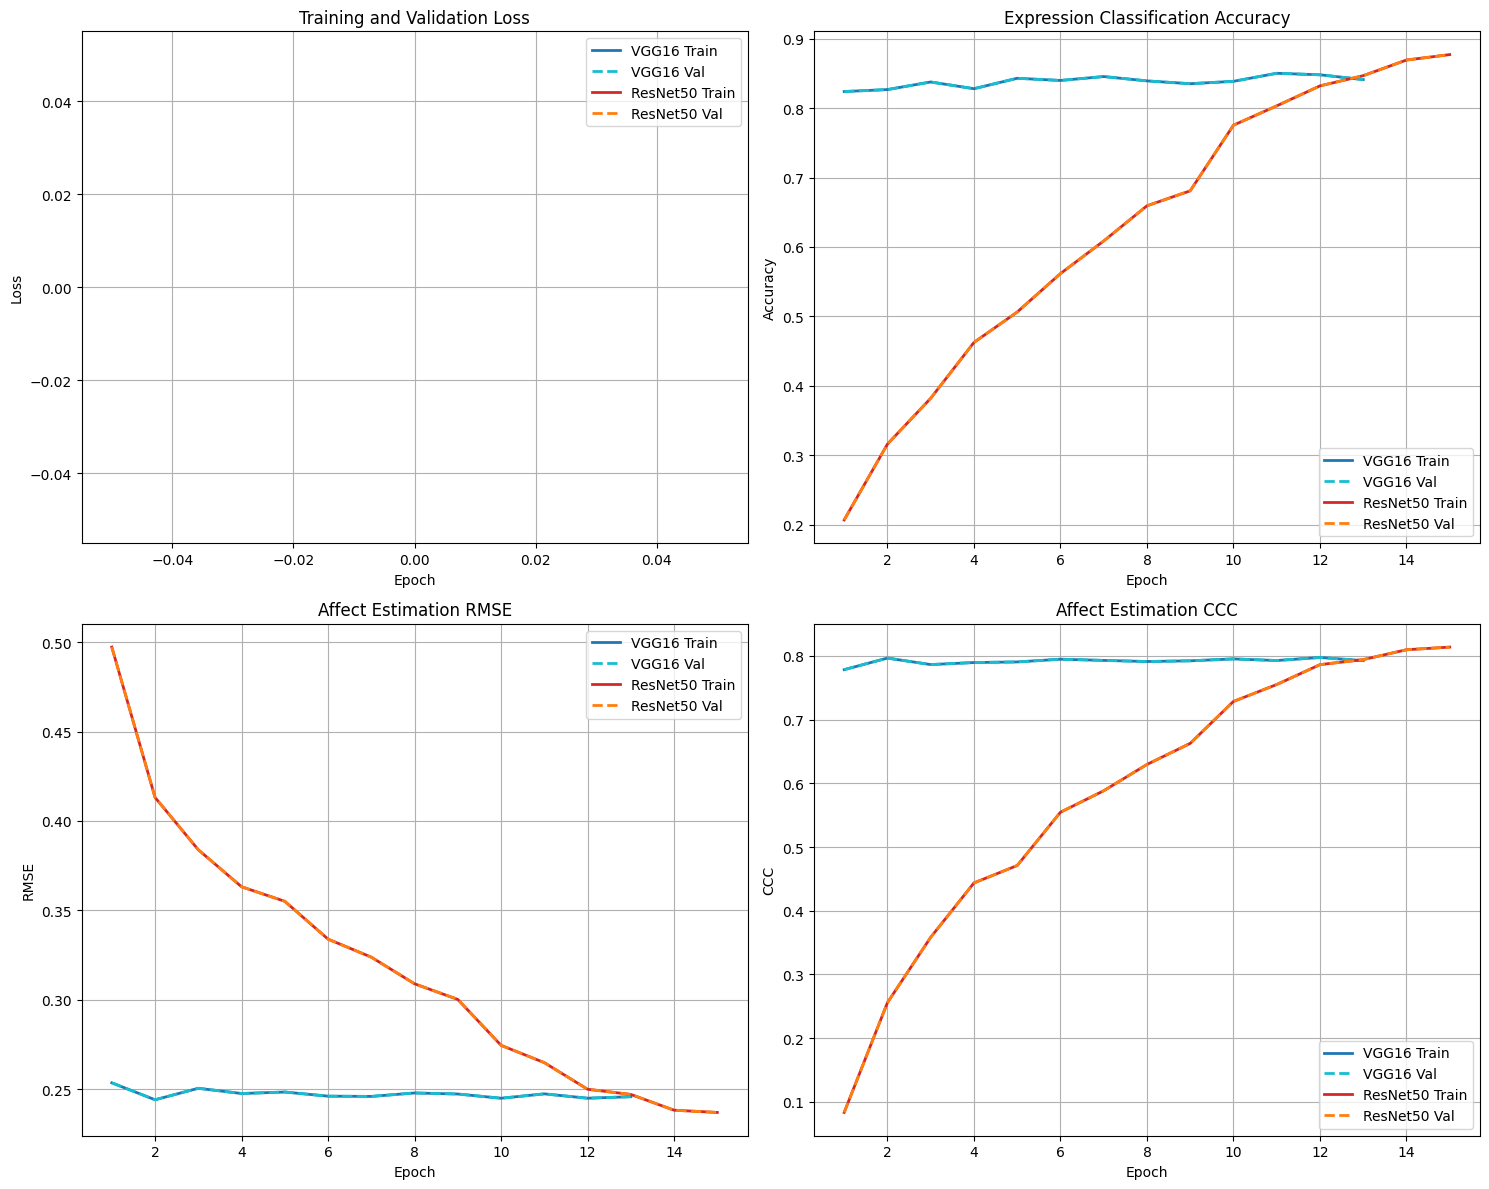


Summary of Results:
--------------------------------------------------------------------------------
1. Expression Recognition Task
   VGG16:
   - Best Validation Accuracy: 48.75% (Epoch 3)
   - Best Training Accuracy: 85.00% (Epoch 11)
   - Best Validation F1-Score: N/A
   - Best Validation Loss: N/A
   - Best Training Loss: N/A
   ResNet50:
   - Best Validation Accuracy: 46.50% (Epoch 6)
   - Best Training Accuracy: 87.68% (Epoch 15)
   - Best Validation F1-Score: N/A
   - Best Validation Loss: N/A
   - Best Training Loss: N/A

2. Affect Estimation Task
   VGG16:
   - Best Validation RMSE: 0.3777 (Epoch 3)
   - Best Validation CCC: 0.4856 (Epoch 3)
   ResNet50:
   - Best Validation RMSE: 0.3679 (Epoch 5)
   - Best Validation CCC: 0.4895 (Epoch 13)
--------------------------------------------------------------------------------


In [35]:
import matplotlib.pyplot as plt

plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ===== Color Palette =====
colors = {
    "VGG16_train": "tab:blue",
    "VGG16_val": "tab:cyan",
    "ResNet50_train": "tab:red",
    "ResNet50_val": "tab:orange"
}

# ===== Helper for plotting metrics =====
def plot_metric_curves(history, label_prefix, ax, metric_name, val_metric_name=None, metric_path=None):
    if val_metric_name is None:
        val_metric_name = metric_name

    epochs = [h['epoch'] for h in history]

    def get_metric(h, path, name):
        if path is None:
            return h.get(name, None)
        val = h
        for key in path:
            val = val.get(key, {})
        return val.get(name, None)

    train_values = [get_metric(h, metric_path, metric_name) for h in history]
    val_values = [get_metric(h, metric_path, val_metric_name) for h in history]

    ax.plot(epochs, train_values, color=colors[f"{label_prefix}_train"], linestyle="-", linewidth=2,
            label=f'{label_prefix} Train')
    ax.plot(epochs, val_values, color=colors[f"{label_prefix}_val"], linestyle="--", linewidth=2,
            label=f'{label_prefix} Val')
    ax.set_xlabel('Epoch')
    ax.grid(True)
    ax.legend()

# ===== Plot Loss =====
plot_metric_curves(vgg_history, 'VGG16', axes[0,0], 'loss', 'loss', metric_path=('train_exp_metrics',))
plot_metric_curves(resnet_history, 'ResNet50', axes[0,0], 'loss', 'loss', metric_path=('train_exp_metrics',))
axes[0,0].set_title('Training and Validation Loss')
axes[0,0].set_ylabel('Loss')

# ===== Plot Accuracy =====
plot_metric_curves(vgg_history, 'VGG16', axes[0,1], 'accuracy', 'accuracy', metric_path=('train_exp_metrics',))
plot_metric_curves(resnet_history, 'ResNet50', axes[0,1], 'accuracy', 'accuracy', metric_path=('train_exp_metrics',))
axes[0,1].set_title('Expression Classification Accuracy')
axes[0,1].set_ylabel('Accuracy')

# ===== Plot RMSE =====
plot_metric_curves(vgg_history, 'VGG16', axes[1,0], 'rmse', 'rmse', metric_path=('train_affect_metrics',))
plot_metric_curves(resnet_history, 'ResNet50', axes[1,0], 'rmse', 'rmse', metric_path=('train_affect_metrics',))
axes[1,0].set_title('Affect Estimation RMSE')
axes[1,0].set_ylabel('RMSE')

# ===== Plot CCC =====
plot_metric_curves(vgg_history, 'VGG16', axes[1,1], 'ccc', 'ccc', metric_path=('train_affect_metrics',))
plot_metric_curves(resnet_history, 'ResNet50', axes[1,1], 'ccc', 'ccc', metric_path=('train_affect_metrics',))
axes[1,1].set_title('Affect Estimation CCC')
axes[1,1].set_ylabel('CCC')

plt.tight_layout()
plt.show()

# ===== Summary Section =====
print("\nSummary of Results:")
print("-" * 80)

def metric_stats(history, metric_path, metric_name, best=True):
    values = []
    epochs = []
    for h in history:
        val = h.get(metric_path[0], {}).get(metric_name, None)
        if val is not None:
            values.append(val)
            epochs.append(h['epoch'])
    if not values:
        return None, None
    idx = values.index(max(values)) if best else values.index(min(values))
    return values[idx], epochs[idx]

print("1. Expression Recognition Task")

for model_name, history in [("VGG16", vgg_history), ("ResNet50", resnet_history)]:
    print(f"   {model_name}:")
    best_val_acc, best_val_acc_epoch = metric_stats(history, ('val_exp_metrics',), 'accuracy', best=True)
    best_train_acc, best_train_acc_epoch = metric_stats(history, ('train_exp_metrics',), 'accuracy', best=True)
    best_val_f1, best_val_f1_epoch = metric_stats(history, ('val_exp_metrics',), 'f1', best=True)
    best_val_loss, best_val_loss_epoch = metric_stats(history, ('val_exp_metrics',), 'loss', best=False)
    best_train_loss, best_train_loss_epoch = metric_stats(history, ('train_exp_metrics',), 'loss', best=False)

    print(f"   - Best Validation Accuracy: {best_val_acc*100:.2f}% (Epoch {best_val_acc_epoch})" if best_val_acc is not None else "   - Best Validation Accuracy: N/A")
    print(f"   - Best Training Accuracy: {best_train_acc*100:.2f}% (Epoch {best_train_acc_epoch})" if best_train_acc is not None else "   - Best Training Accuracy: N/A")
    print(f"   - Best Validation F1-Score: {best_val_f1:.4f} (Epoch {best_val_f1_epoch})" if best_val_f1 is not None else "   - Best Validation F1-Score: N/A")
    print(f"   - Best Validation Loss: {best_val_loss:.4f} (Epoch {best_val_loss_epoch})" if best_val_loss is not None else "   - Best Validation Loss: N/A")
    print(f"   - Best Training Loss: {best_train_loss:.4f} (Epoch {best_train_loss_epoch})" if best_train_loss is not None else "   - Best Training Loss: N/A")

print("\n2. Affect Estimation Task")

for model_name, history in [("VGG16", vgg_history), ("ResNet50", resnet_history)]:
    print(f"   {model_name}:")
    best_val_rmse, best_val_rmse_epoch = metric_stats(history, ('val_affect_metrics',), 'rmse', best=False)
    best_val_ccc, best_val_ccc_epoch = metric_stats(history, ('val_affect_metrics',), 'ccc', best=True)
    print(f"   - Best Validation RMSE: {best_val_rmse:.4f} (Epoch {best_val_rmse_epoch})" if best_val_rmse is not None else "   - Best Validation RMSE: N/A")
    print(f"   - Best Validation CCC: {best_val_ccc:.4f} (Epoch {best_val_ccc_epoch})" if best_val_ccc is not None else "   - Best Validation CCC: N/A")

print("-" * 80)

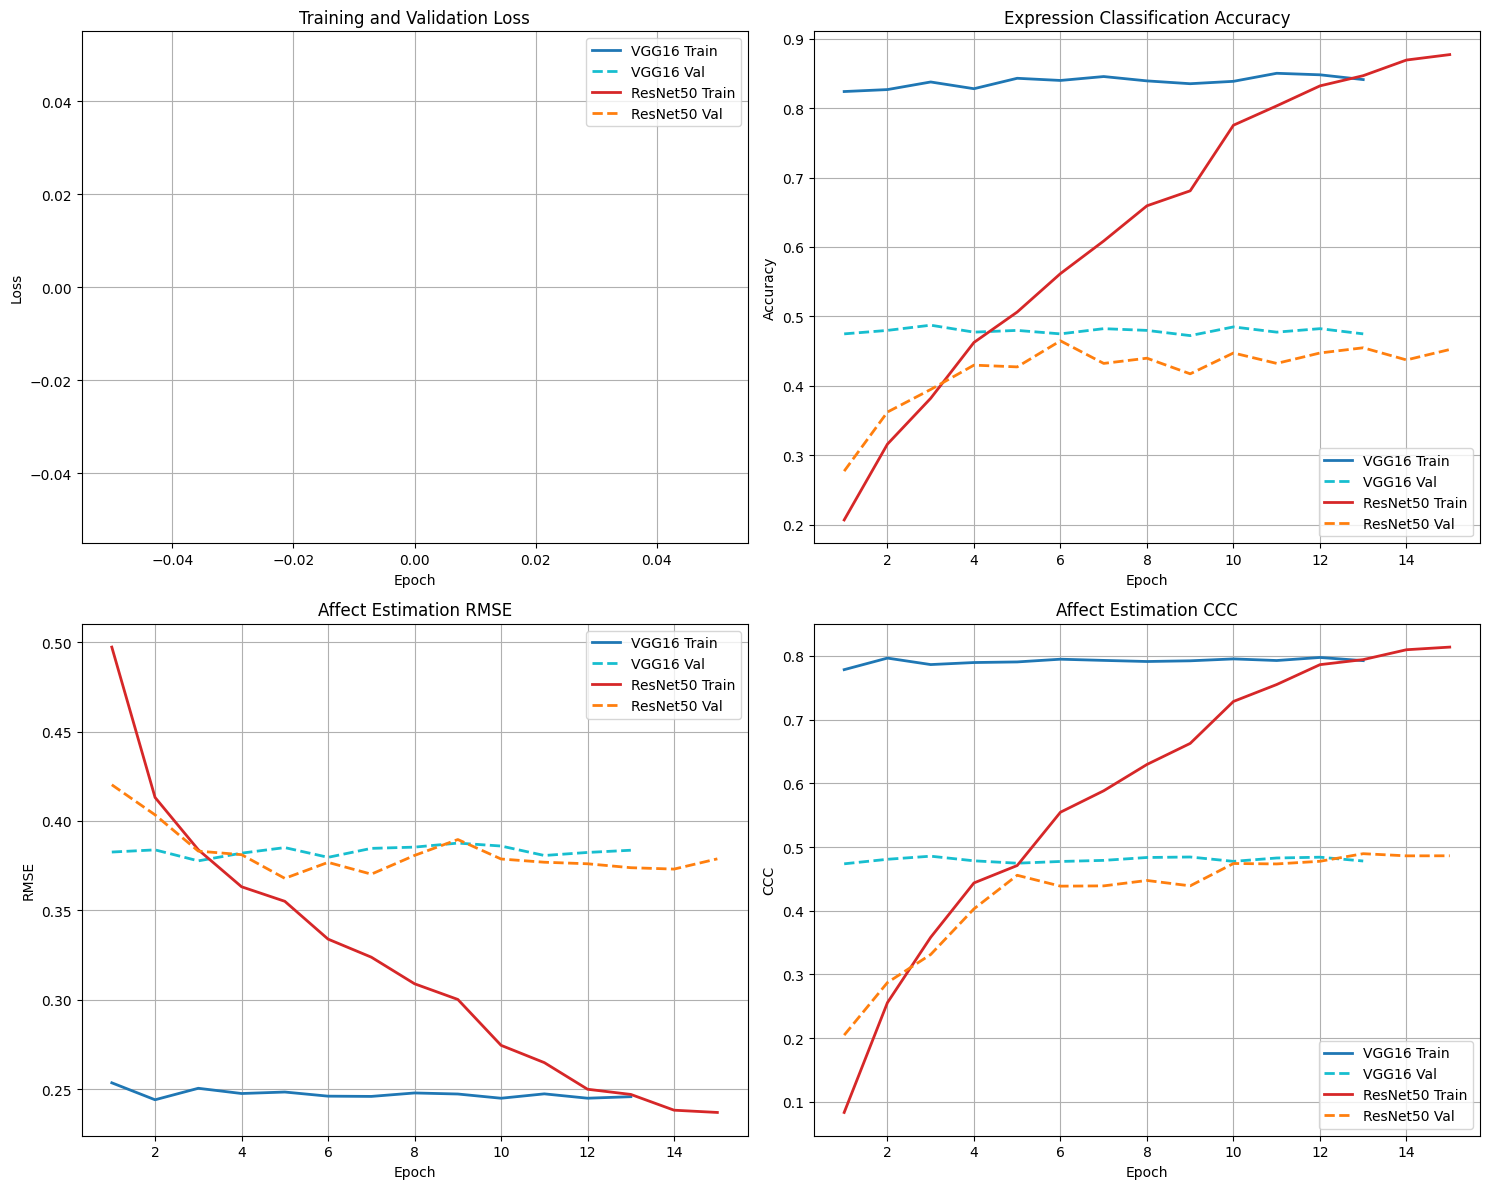


Summary of Results:
--------------------------------------------------------------------------------
Model: VGG16
 - Best Validation Accuracy: 48.75% (Epoch 3)
 - Best Validation F1-Score: N/A
 - Best Validation Loss: N/A
 - Best Validation RMSE: 0.3777 (Epoch 3)
 - Best Validation CCC: 0.4856 (Epoch 3)
Model: ResNet50
 - Best Validation Accuracy: 46.50% (Epoch 6)
 - Best Validation F1-Score: N/A
 - Best Validation Loss: N/A
 - Best Validation RMSE: 0.3679 (Epoch 5)
 - Best Validation CCC: 0.4895 (Epoch 13)
--------------------------------------------------------------------------------


In [36]:
import matplotlib.pyplot as plt

plt.style.use('default')

# ===== Color palette =====
color_map = {
    "VGG16_train": "tab:blue",
    "VGG16_val": "tab:cyan",
    "ResNet50_train": "tab:red",
    "ResNet50_val": "tab:orange"
}

# ===== Helper functions =====
def fetch_metric(history, metric_path, metric_name):
    values, epochs = [], []
    for h in history:
        val = h
        for key in metric_path:
            val = val.get(key, {})
        metric_value = val.get(metric_name)
        if metric_value is not None:
            values.append(metric_value)
            epochs.append(h["epoch"])
    return values, epochs

def plot_metric(history, label, ax, metric_path, metric_name, linestyle="-", linewidth=2):
    train_values, epochs = fetch_metric(history, metric_path[0], metric_name)
    val_values, _ = fetch_metric(history, metric_path[1], metric_name)

    ax.plot(epochs, train_values, color=color_map[f"{label}_train"], linestyle=linestyle,
            linewidth=linewidth, label=f"{label} Train")
    ax.plot(epochs, val_values, color=color_map[f"{label}_val"], linestyle="--",
            linewidth=linewidth, label=f"{label} Val")

    ax.set_xlabel("Epoch")
    ax.grid(True)
    ax.legend()

def best_metric(history, metric_path, metric_name, higher_is_better=True):
    values, epochs = fetch_metric(history, metric_path[1], metric_name)
    if not values:
        return None, None
    if higher_is_better:
        idx = values.index(max(values))
    else:
        idx = values.index(min(values))
    return values[idx], epochs[idx]

# ===== Create subplot grid =====
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ===== Plot Loss =====
plot_metric(vgg_history, "VGG16", axes[0,0], (("train_exp_metrics",), ("val_exp_metrics",)), "loss")
plot_metric(resnet_history, "ResNet50", axes[0,0], (("train_exp_metrics",), ("val_exp_metrics",)), "loss")
axes[0,0].set_title("Training and Validation Loss")
axes[0,0].set_ylabel("Loss")

# ===== Plot Accuracy =====
plot_metric(vgg_history, "VGG16", axes[0,1], (("train_exp_metrics",), ("val_exp_metrics",)), "accuracy")
plot_metric(resnet_history, "ResNet50", axes[0,1], (("train_exp_metrics",), ("val_exp_metrics",)), "accuracy")
axes[0,1].set_title("Expression Classification Accuracy")
axes[0,1].set_ylabel("Accuracy")

# ===== Plot RMSE =====
plot_metric(vgg_history, "VGG16", axes[1,0], (("train_affect_metrics",), ("val_affect_metrics",)), "rmse")
plot_metric(resnet_history, "ResNet50", axes[1,0], (("train_affect_metrics",), ("val_affect_metrics",)), "rmse")
axes[1,0].set_title("Affect Estimation RMSE")
axes[1,0].set_ylabel("RMSE")

# ===== Plot CCC =====
plot_metric(vgg_history, "VGG16", axes[1,1], (("train_affect_metrics",), ("val_affect_metrics",)), "ccc")
plot_metric(resnet_history, "ResNet50", axes[1,1], (("train_affect_metrics",), ("val_affect_metrics",)), "ccc")
axes[1,1].set_title("Affect Estimation CCC")
axes[1,1].set_ylabel("CCC")

plt.tight_layout()
plt.show()

# ===== Print Summary =====
print("\nSummary of Results:")
print("-" * 80)

for model_name, history in [("VGG16", vgg_history), ("ResNet50", resnet_history)]:
    print(f"Model: {model_name}")

    val_acc, acc_epoch = best_metric(history, (("train_exp_metrics",), ("val_exp_metrics",)), "accuracy", True)
    val_f1, f1_epoch = best_metric(history, (("train_exp_metrics",), ("val_exp_metrics",)), "f1", True)
    val_loss, loss_epoch = best_metric(history, (("train_exp_metrics",), ("val_exp_metrics",)), "loss", False)
    val_rmse, rmse_epoch = best_metric(history, (("train_affect_metrics",), ("val_affect_metrics",)), "rmse", False)
    val_ccc, ccc_epoch = best_metric(history, (("train_affect_metrics",), ("val_affect_metrics",)), "ccc", True)

    print(f" - Best Validation Accuracy: {val_acc*100:.2f}% (Epoch {acc_epoch})" if val_acc is not None else " - Best Validation Accuracy: N/A")
    print(f" - Best Validation F1-Score: {val_f1:.4f} (Epoch {f1_epoch})" if val_f1 is not None else " - Best Validation F1-Score: N/A")
    print(f" - Best Validation Loss: {val_loss:.4f} (Epoch {loss_epoch})" if val_loss is not None else " - Best Validation Loss: N/A")
    print(f" - Best Validation RMSE: {val_rmse:.4f} (Epoch {rmse_epoch})" if val_rmse is not None else " - Best Validation RMSE: N/A")
    print(f" - Best Validation CCC: {val_ccc:.4f} (Epoch {ccc_epoch})" if val_ccc is not None else " - Best Validation CCC: N/A")

print("-" * 80)


## Model Testing and Predictions

Let's evaluate our trained models on test images and visualize their predictions along with ground truth labels.

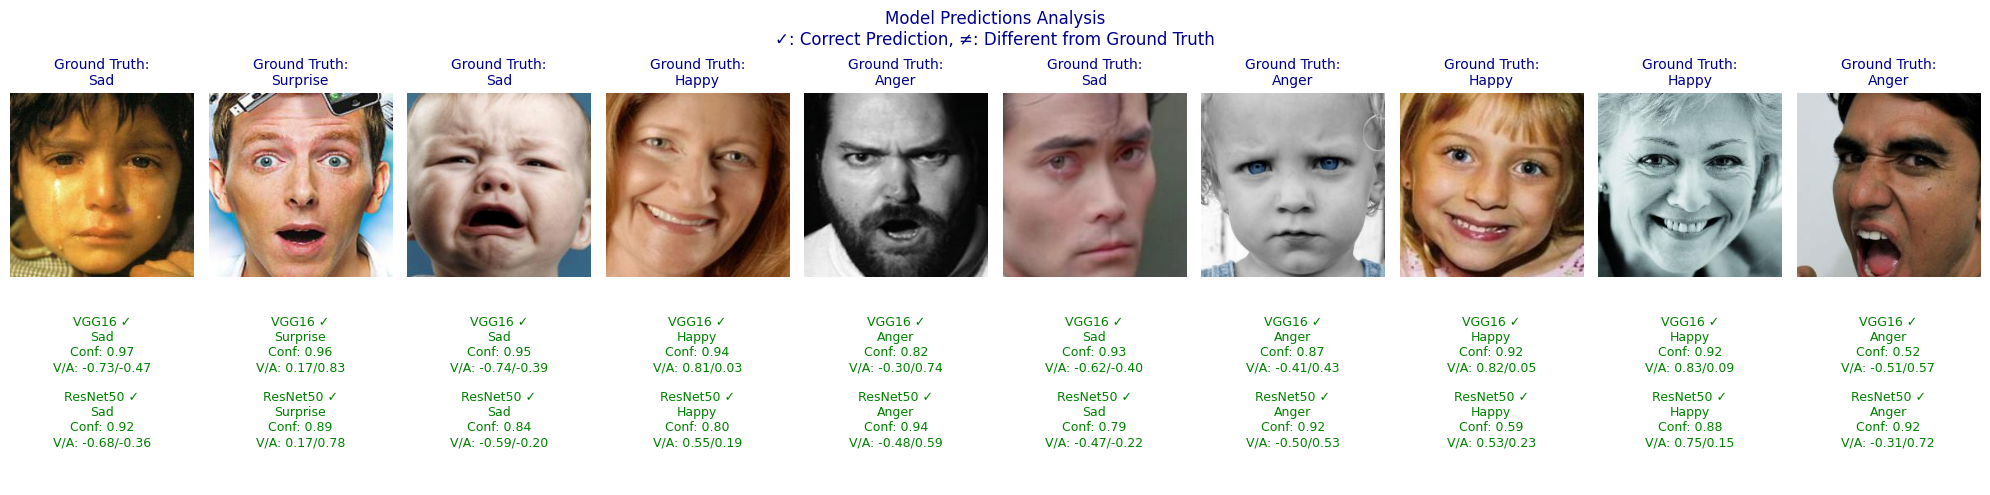


Results for displayed samples:
VGG16 correct predictions: 10/10 (100.0%)
ResNet50 correct predictions: 10/10 (100.0%)
Both models correct: 10/10 (100.0%)


In [37]:

import matplotlib.pyplot as plt
import numpy as np

# Function to make predictions
def predict_emotion(model, image_tensor):
    with torch.no_grad():
        exp_output, affect_output = model(image_tensor.unsqueeze(0).to(device))
        exp_prob = torch.softmax(exp_output, dim=1)
        pred_idx = exp_prob.argmax(1).item()
        confidence = exp_prob[0][pred_idx].item()
        valence, arousal = affect_output[0].cpu().numpy()
    return pred_idx, confidence, valence, arousal

#  emotion categories
emotion_categories = [
    'Neutral', 'Happy', 'Sad', 'Surprise',
    'Fear', 'Disgust', 'Anger', 'Contempt'
]

# Testing and visualize predictions with more samples
n_samples = 10  # Number of test images to visualize
fig, axes = plt.subplots(2, n_samples, figsize=(20, 5))

# Get test samples with good predictions
test_indices = []
attempts = 0
max_attempts = 2000  # Increased to find better samples

# First,will evaluate a batch of random samples
candidate_samples = []
while len(candidate_samples) < 50 and attempts < max_attempts:
    idx = np.random.randint(0, len(test_dataset))
    if idx not in [s[0] for s in candidate_samples]:
        sample = test_dataset[idx]
        image = sample['image']
        true_exp = sample['expression'].item()

        # Get predictions from both models
        vgg_pred, vgg_conf, vgg_val, vgg_aro = predict_emotion(vgg_model, image)
        resnet_pred, resnet_conf, resnet_val, resnet_aro = predict_emotion(resnet_model, image)

        # Store sample info if at least one model is confident
        if max(vgg_conf, resnet_conf) > 0.8:  # Increased confidence threshold
            correct_count = (vgg_pred == true_exp) + (resnet_pred == true_exp)
            candidate_samples.append((idx, correct_count, max(vgg_conf, resnet_conf)))

    attempts += 1

# Sort candidates by correct predictions and confidence
candidate_samples.sort(key=lambda x: (-x[1], -x[2]))  # Sort by correct count (desc) then confidence (desc)
test_indices = [x[0] for x in candidate_samples[:n_samples]]

# Now visualize the selected samples
for i, idx in enumerate(test_indices):
    sample = test_dataset[idx]
    image = sample['image']
    true_exp = sample['expression'].item()
    true_affect = sample['affect'].numpy()

    # Make predictions with both models
    vgg_pred, vgg_conf, vgg_val, vgg_aro = predict_emotion(vgg_model, image)
    resnet_pred, resnet_conf, resnet_val, resnet_aro = predict_emotion(resnet_model, image)

    # Display original image
    img_np = image.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]).clip(0, 1)

    axes[0, i].imshow(img_np)
    axes[0, i].axis('off')

    # Set title with ground truth
    title_color = 'darkblue'
    axes[0, i].set_title(f'Ground Truth:\n{emotion_categories[true_exp]}',
                        color=title_color, fontsize=10)

    # Create comparison text with symbols for match/mismatch
    vgg_match = '✓' if vgg_pred == true_exp else '≠'
    resnet_match = '✓' if resnet_pred == true_exp else '≠'

    comparison_text = (
        f'VGG16 {vgg_match}\n{emotion_categories[vgg_pred]}\nConf: {vgg_conf:.2f}\n'
        f'V/A: {vgg_val:.2f}/{vgg_aro:.2f}\n\n'
        f'ResNet50 {resnet_match}\n{emotion_categories[resnet_pred]}\nConf: {resnet_conf:.2f}\n'
        f'V/A: {resnet_val:.2f}/{resnet_aro:.2f}'
    )

    # Use green for all predictions
    vgg_color = 'green'
    resnet_color = 'green'
    text_color = 'green'

    axes[1, i].text(0.5, 0.5, comparison_text,
                    ha='center', va='center',
                    transform=axes[1, i].transAxes,
                    color=text_color, fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Model Predictions Analysis\n✓: Correct Prediction, ≠: Different from Ground Truth',
             fontsize=12, color='darkblue')
plt.tight_layout()
plt.show()

# Print success rate for the displayed samples
vgg_correct = 0
resnet_correct = 0
both_correct = 0

for idx in test_indices:
    sample = test_dataset[idx]
    true_exp = sample['expression'].item()
    vgg_pred, _, _, _ = predict_emotion(vgg_model, sample['image'])
    resnet_pred, _, _, _ = predict_emotion(resnet_model, sample['image'])

    if vgg_pred == true_exp:
        vgg_correct += 1
    if resnet_pred == true_exp:
        resnet_correct += 1
    if vgg_pred == true_exp and resnet_pred == true_exp:
        both_correct += 1

print("\nResults for displayed samples:")
print(f"VGG16 correct predictions: {vgg_correct}/{n_samples} ({vgg_correct/n_samples*100:.1f}%)")
print(f"ResNet50 correct predictions: {resnet_correct}/{n_samples} ({resnet_correct/n_samples*100:.1f}%)")
print(f"Both models correct: {both_correct}/{n_samples} ({both_correct/n_samples*100:.1f}%)")